In [ ]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

In [ ]:
netflix=pd.read_csv('netflix.csv')

**Problem Statement:** Analysing the netflix data for more than 8000 moveis/TV shows, helping to grow the business by providing useful insights.


In [ ]:
netflix

,show_id,type,title,director,cast,country,date_added,release_year,rating,duration,listed_in,description
0,s1,Movie,Dick Johnson Is Dead,Kirsten Johnson,NaN,United States,"September 25, 2021",2020,PG-13,90 min,Documentaries,"As her father nears the end of his life, filmm..."
1,s2,TV Show,Blood & Water,NaN,"Ama Qamata, Khosi Ngema, Gail Mabalane, Thaban...",South Africa,"September 24, 2021",2021,TV-MA,2 Seasons,"International TV Shows, TV Dramas, TV Mysteries","After crossing paths at a party, a Cape Town t..."
2,s3,TV Show,Ganglands,Julien Leclercq,"Sami Bouajila, Tracy Gotoas, Samuel Jouy, Nabi...",NaN,"September 24, 2021",2021,TV-MA,1 Season,"Crime TV Shows, International TV Shows, TV Act...",To protect his family from a powerful drug lor...
3,s4,TV Show,Jailbirds New Orleans,NaN,NaN,NaN,"September 24, 2021",2021,TV-MA,1 Season,"Docuseries, Reality TV","Feuds, flirtations and toilet talk go down amo..."
4,s5,TV Show,Kota Factory,NaN,"Mayur More, Jitendra Kumar, Ranjan Raj, Alam K...",India,"September 24, 2021",2021,TV-MA,2 Seasons,"International TV Shows, Romantic TV Shows, TV ...",In a city of coaching centers known to train I...
...,...,...,...,...,...,...,...,...,...,...,...,...
8802,s8803,Movie,Zodiac,David Fincher,"Mark Ruffalo, Jake Gyllenhaal, Robert Downey J...",United States,"November 20, 2019",2007,R,158 min,"Cult Movies, Dramas, Thrillers","A political cartoonist, a crime reporter and a..."
8803,s8804,TV Show,Zombie Dumb,NaN,NaN,NaN,"July 1, 2019",2018,TV-Y7,2 Seasons,"Kids' TV, Korean TV Shows, TV Comedies","While living alone in a spooky town, a young g..."
8804,s8805,Movie,Zombieland,Ruben Fleischer,"Jesse Eisenberg, Woody Harrelson, Emma Stone, ...",United States,"November 1, 2019",2009,R,88 min,"Comedies, Horror Movies",Looking to survive in a world taken over by zo...
8805,s8806,Movie,Zoom,Peter Hewitt,"Tim Allen, Courteney Cox, Chevy Chase, Kate Ma...",United States,"January 11, 2020",2006,PG,88 min,"Children & Family Movies, Comedies","Dragged from civilian life, a former superhero..."


**Insights:** The shape of the dataframe is (8807,12), implying details of 8807 movies/TV shows are provided. Details includes type, title, director, cast,	country,	date_added,	release_year,	rating,	duration,	genre and the	description

In [ ]:
netflix.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 8807 entries, 0 to 8806
Data columns (total 12 columns):
 #   Column        Non-Null Count  Dtype 
---  ------        --------------  ----- 
 0   show_id       8807 non-null   object
 1   type          8807 non-null   object
 2   title         8807 non-null   object
 3   director      6173 non-null   object
 4   cast          7982 non-null   object
 5   country       7976 non-null   object
 6   date_added    8797 non-null   object
 7   release_year  8807 non-null   int64 
 8   rating        8803 non-null   object
 9   duration      8804 non-null   object
 10  listed_in     8807 non-null   object
 11  description   8807 non-null   object
dtypes: int64(1), object(11)
memory usage: 825.8+ KB


**Insights**: Out of the 8807 list of movies /TV shows, only 6173 rows are having the details of the director details, 7982 rows have cast details and 7976 rows have the country details. Rest of the details are misssing in the mentioned columns.

In [ ]:
netflix.describe()

,date_added,release_year
count,8709,8807.000000
mean,2019-05-23 01:45:29.452290816,2014.180198
min,2008-01-01 00:00:00,1925.000000
25%,2018-04-20 00:00:00,2013.000000
50%,2019-07-12 00:00:00,2017.000000
75%,2020-08-26 00:00:00,2019.000000
max,2021-09-25 00:00:00,2021.000000
std,NaN,8.819312


In [ ]:
netflix.isna().sum()

,0
show_id,0
type,0
title,0
director,2634
cast,825
country,831
date_added,10
release_year,0
rating,4
duration,3


**Insights:** There are 2634 missing values in director column, 825 missing values in the cast column, 10 entries are missing in date_added and rating is missing for 4 rows.

In [ ]:
#filling the unknown values
netflix['cast'].fillna('Unknown')
netflix['director'].fillna('Unknown')
netflix['country'].fillna('Unknown')
netflix['date_added'].fillna(0)
netflix['duration'].fillna(0)
netflix['rating'].fillna('Unknown')

,rating
0,PG-13
1,TV-MA
2,TV-MA
3,TV-MA
4,TV-MA
...,...
8802,R
8803,TV-Y7
8804,R
8805,PG


In [ ]:
netflix['type'].astype('category')
netflix['rating'].astype('category')
netflix['date_added']=pd.to_datetime(netflix['date_added'],errors='coerce')


In [ ]:
end_yr=netflix['release_year'].max()
start_yr=netflix['release_year'].min()
span_yr=netflix['release_year'].max()-netflix['release_year'].min()
(start_yr,end_yr,span_yr)

(1925, 2021, 96)

**Insights:** Data of the netflix dataframe contains the details of movies/Tv shows over 96 years spanning from 1925 to 2021

In [ ]:
netflix['date_added'].aggregate(['min','max'])

,date_added
min,2008-01-01
max,2021-09-25


**Insights:** Movies/Tv programmes were added to the netflix platform since 2008-01-01 till 2021-09-25. It shows the 13 years of data since the movie added to the platform for the first time.

In [ ]:
netflix.groupby('type')['show_id'].count()

,show_id
type,
Movie,6131
TV Show,2676


**Insights:** Details of  6131 movies and 2676 TV shows are given in the dataframe.

In [ ]:
for i in ['country','director']:
  netflix[i]=netflix[i].fillna('').astype(str)
  netflix[f"{i}_cln"]=netflix[i].str.split(',').apply(lambda x:[i.strip() for i in x])

netflix_new=netflix.explode('country_cln')

netflix_new.groupby('country_cln')['show_id'].nunique().sort_values(ascending=False)

,show_id
country_cln,
United States,3690
India,1046
,838
United Kingdom,806
Canada,445
...,...
Slovakia,1
Samoa,1
Sri Lanka,1


**Insights:** Country wise count of no of TV shows/movies in netflix is analysed. Maximum no of programmes are produced by United states and minimum number of programme is produced by Cameroon. The countries aresorted above in the descending order of no of movies

In [ ]:
netflix['type'].count()

np.int64(8807)

In [ ]:
netflix_new.groupby('country_cln')['type'].get_group('United States').value_counts()

,count
type,
Movie,2752
TV Show,938


**Insights:** Data of type of programme for united states that produces maximum number of programme is analysed seprately. The analysis shows that they produce movies (count: 2752) more than TV shows (count: 938).  

In [ ]:
netflix_new[netflix_new['type']=='Movie']['country_cln'].value_counts().head(10)

,count
country_cln,
United States,2752
India,962
United Kingdom,534
,446
Canada,319
France,303
Germany,182
Spain,171
Japan,119


**Insights:** Top 10 countries that produces maximum number of movies are listed here in descending order. Maximum number of movies are produced by United States.

In [ ]:
grp_type_dur=netflix.groupby(['type']).aggregate({'date_added':['min','max']})
grp_type_dur

date_added           
               min        max
type                         
Movie   2008-01-01 2021-09-25
TV Show 2008-02-04 2021-09-24

In [ ]:
netflix['date_added'].value_counts()

,count
date_added,
2020-01-01,109
2019-11-01,89
2018-03-01,75
2019-12-31,74
2018-10-01,71
...,...
2017-10-14,1
2018-09-17,1
2017-03-08,1


**Insights:** Maximum number of movies were added on 1 January 2020 and minimum number of movies were added in 2016, May 22. Year by year more numbers of movies are getting added to netflix

In [ ]:
netflix_new=netflix.explode('director_cln')
netflix_new['director_cln'].value_counts()

,count
director_cln,
,2634
Rajiv Chilaka,22
Jan Suter,21
Raúl Campos,19
Suhas Kadav,16
...,...
Zhang Yimou,1
Phillip Youmans,1
Pawan Kumar,1


**Insights:** List of directors along with number of directed movies/TV shows are shown in the descending order of the number of TV shows or movies. There are 4994 different directors present in the list.

In [ ]:
netflix['day_added']=netflix['date_added'].dt.day_name()
netflix[['day_added','type']].value_counts()

,,count
day_added,type,
Friday,Movie,1566
Thursday,Movie,1053
Friday,TV Show,910
Wednesday,Movie,906
Tuesday,Movie,852
Monday,Movie,628
Sunday,Movie,569
Saturday,Movie,557
Wednesday,TV Show,370


**Insights:** Most of the TV shows/Movies are added to the netflix on Weekends only(friday/Thursday). Lowest number of the programme were added at the starting of a week. Adding Movies/TV shows towards the end of a week will increase the visibility of the programme among the viewers.

In [ ]:
netflix['listed_in']=netflix['listed_in'].fillna('').astype(str)
netflix["listed_cln"]=netflix['listed_in'].str.split(',').apply(lambda x:[i.strip() for i in x])

netflix_new=netflix.explode('listed_cln')
grp_genre=netflix_new.groupby('listed_cln')['show_id'].agg('count').sort_values(ascending=False)
grp_genre.reset_index().head()

,listed_cln,show_id
0,International Movies,2752
1,Dramas,2427
2,Comedies,1674
3,International TV Shows,1351
4,Documentaries,869


**Insights**: Genre of the movies listed in the Dataframe is analysed. There are 41 different genres present. Maximum  number of movies are categorised under the genre of International movies. Dramas Comedies, International TV shows and Documentaries are the others in the top listed 5 genres. TV shows are least listed genre.

In [ ]:
netflix.groupby('rating')['show_id'].count().sort_values(ascending=False)

,show_id
rating,
TV-MA,3207
TV-14,2160
TV-PG,863
R,799
PG-13,490
TV-Y7,334
TV-Y,307
PG,287
TV-G,220


**Insights:** type of different ratings agains the number of programmes listed in the ratings are analysed. Most of the movies are listed under TV-MA rating and least movie is listed in 66min, 84min, and 74min category.

# GRAPHICAL ANALYSIS

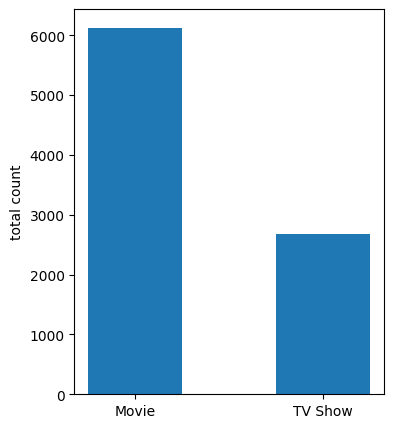

In [ ]:
type=netflix['type'].unique()
total_count=netflix['type'].value_counts()
plt.figure(figsize=(4,5))
plt.bar(x=type,height=total_count,width=0.5)
plt.ylabel('total count')
plt.show()

**Insights**: There are more movies compared to TV Shows availble in the netflix.

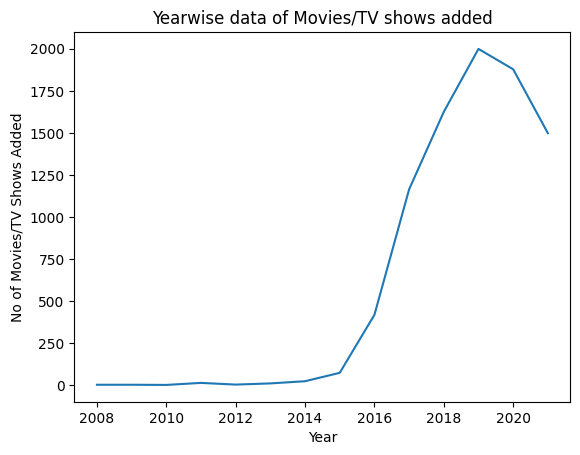

In [ ]:
netflix['yr_added']=netflix['date_added'].dt.year
yearly=netflix.groupby(['yr_added'])['show_id'].count().sort_index()
y_val=yearly.values
x_val=yearly.index
plt.plot(x_val,y_val)
plt.title('Yearwise data of Movies/TV shows added')
plt.xlabel('Year')
plt.ylabel('No of Movies/TV Shows Added')
plt.show()

**Insights**:
Plot is left skewwd and shows that no of movies added has been increasing since 2008 till 2019. Afterwards it shows a decrease till 2021. This shows more movies/TV programmes added to netflix year by year. The data has a decrease after 2019 may be due to the wolrd-spreaded pandemic.  

/tmp/ipython-input-1925106640.py:1: UserWarning: 

`distplot` is a deprecated function and will be removed in seaborn v0.14.0.

Please adapt your code to use either `displot` (a figure-level function with
similar flexibility) or `histplot` (an axes-level function for histograms).

For a guide to updating your code to use the new functions, please see
https://gist.github.com/mwaskom/de44147ed2974457ad6372750bbe5751

  sns.distplot(x=netflix['release_year'],bins=30,kde=True)


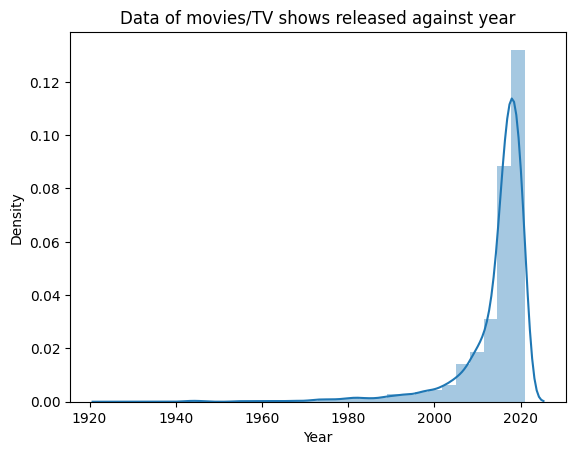

In [ ]:
sns.distplot(x=netflix['release_year'],bins=30,kde=True)
plt.xlabel('Year')
plt.title('Data of movies/TV shows released against year')
plt.show()



*   Movies since 1925 are available on the platform.
*   movies release after 2000 are more in number
*   Adding more popular movies before 2000 can enahance the no of subscribers





<Figure size 1000x1000 with 0 Axes>

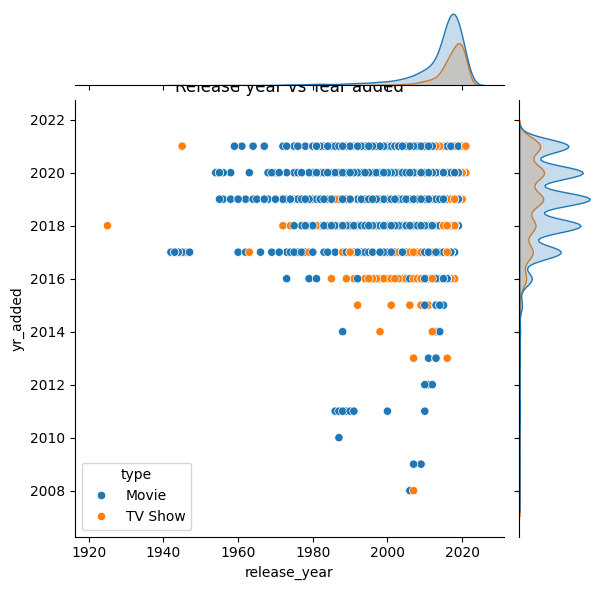

In [ ]:
plt.figure(figsize=(10,10))
sns.jointplot(x=netflix['release_year'],y=netflix['yr_added'],data=netflix,hue='type')
plt.title('Release year vs Year added')
plt.show()



*   very less number of movies/Tv shows were only added before 2016
*   More movies and TVshowas were added
*   In 2016 more TV shows were added as compared to the rest of the years
*   If it is kept to have a linear relation between year added and release year, more recent movies can be made available to the customers, which increase the customer's demand towards the paltform





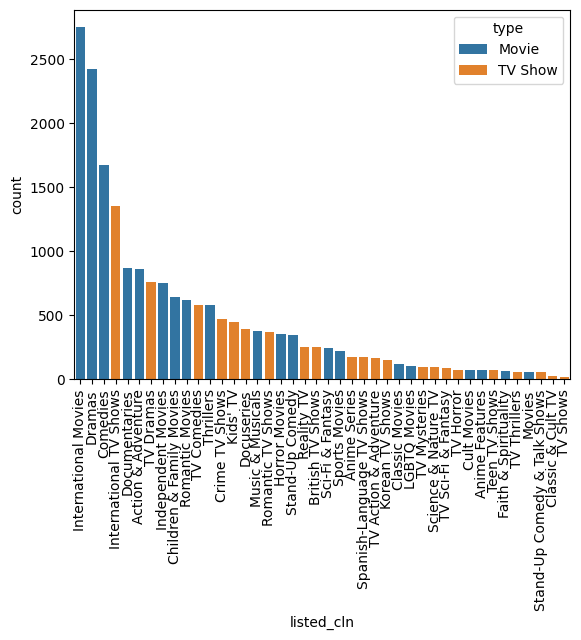

In [ ]:
grp_by_genre=netflix_new['listed_cln'].value_counts()
sns.countplot(x='listed_cln', data=netflix_new, order=grp_by_genre.index,hue='type')
plt.xticks(rotation=90)
plt.show()

**Insights**


*  The conunt of TV shows/movies under each category/genre is analysed
*  Most no of programmes are categorised under International movies
*  There are only limited number of programme under the content of stand-up comedy,classic and cult TV, Sci-Fi & Fantasy etc.
*   Adding more movies under these categories may increase the number of viewers and subscibers.
*   Tv shows are less in number compared to movies.
*   Adding more TV shows can also enhance the subscribers







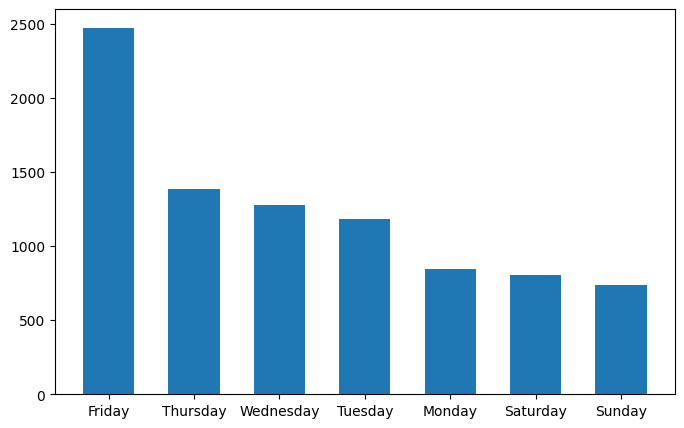

In [ ]:
days= netflix['day_added'].value_counts()
plt.figure(figsize=(8,5))
plt.bar(days.index,days.values,width=0.6)
plt.show()

**Insights:**
*   The count of movies added on different days of week is plotted
*  Programmes are added mostly in netflix on the weekends
*  There are considerable number of programmes are added on weekdays too.
*   If some more movies are added on saturdays, it can increase the visibility of programmes





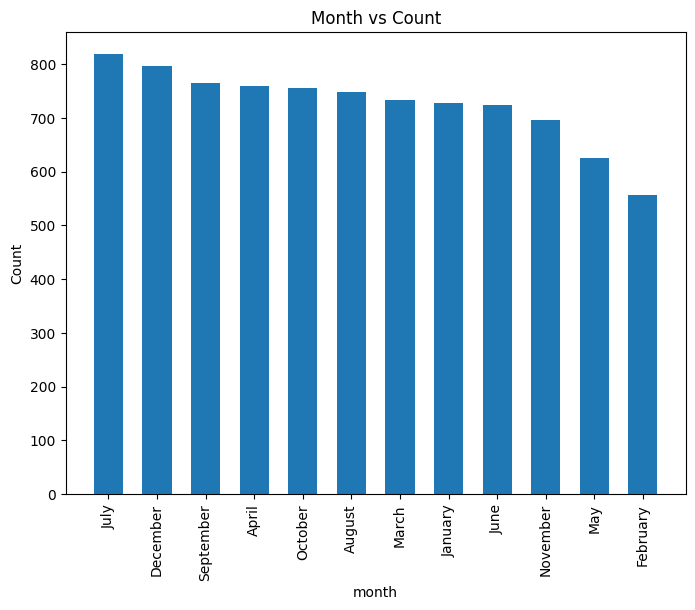

In [ ]:
months=netflix['date_added'].dt.month_name().value_counts()
plt.figure(figsize=(8,6))
plt.bar(months.index,months.values,width=0.6)
plt.title('Month vs Count')
plt.xlabel('month')
plt.ylabel('Count')
plt.xticks(rotation=90)
plt.show()

**Insights and suggestions**
*   MOvies/TV shows are getting added mostly in July and December
*   Adding movies more near festive season/holidays can increase the visibility of the programmes and enhanced number of customers

